# LSTM - Carteira de Utilities Brasileiras (B3)

**Mercado:** B3 - Setor de Transmissão e Geração de Energia Elétrica  
**Ações:** CPFE3 · TAEE11 · EGIE3  
**Framework:** PyTorch  
**Período-base:** 2019 completo + 2023-2024 (treino) | 2025 (holdout)  
**Objetivo desta etapa:** treinar um PortfolioLSTM conjunto com walk-forward CV e avaliá-lo no holdout de 2025

## Instalação de Dependências

In [1]:
# Instala dependencias essenciais com versoes compativeis (Python 3.12).
%pip install --upgrade --force-reinstall --no-cache-dir numpy==2.2.2 scipy==1.15.1 scikit-learn==1.6.1 --quiet
%pip install --upgrade yfinance matplotlib pandas-ta --quiet
print('Dependencias principais instaladas (numpy/scipy/sklearn compativeis).')
print('Se ainda houver erro de import, reinicie o kernel e execute novamente esta celula.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 116.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 MB 121.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 113.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 128.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-ta 0.4.71b0 requires numpy>=2.2.6, but you have numpy 2.2.2 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>

## Imports e Configuração

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings, random, sys, subprocess

warnings.filterwarnings("ignore")

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)

def check_torch_import(timeout_seconds: int = 90):
    """Testa import do torch em subprocesso para evitar travamento silencioso."""
    cmd = [sys.executable, "-c", "import torch; print(torch.__version__)"]
    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout_seconds)
    except subprocess.TimeoutExpired:
        raise RuntimeError(
            "Import de torch excedeu o tempo limite. "
            "No notebook, execute: %pip install --upgrade --force-reinstall --no-cache-dir torch"
        )

    if proc.returncode != 0:
        stderr_msg = (proc.stderr or "").strip()
        raise RuntimeError(
            "Falha ao importar torch no ambiente atual. "
            "No notebook, execute: %pip install --upgrade --force-reinstall --no-cache-dir torch\n"
            f"Detalhe: {stderr_msg}"
        )

    return (proc.stdout or "").strip()

seed_everything(42)
torch_version = check_torch_import(timeout_seconds=90)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas_ta as ta

seed_everything(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE} | PyTorch: {torch.__version__}")
print(f"Check subprocess torch: {torch_version}")

Dispositivo: cpu | PyTorch: 2.10.0+cpu
Check subprocess torch: 2.10.0+cpu


## Coleta de Dados

## Integração com o Conjunto Final de Features

Usamos o conjunto final de variáveis por ticker e o alvo principal `Target_t+5`.

Objetivo desta etapa:
- Reaproveitar a seleção final de variáveis por ticker.
- Construir alvos por horizonte (`t+1`, `t+3`, `t+5`), com foco em `t+5`.
- Entregar um dataset pronto para modelagem LSTM.

Coletando dados brutos por ticker...
CPFE3.SA: 2019-01-02 -> 2025-12-30 | 997 pregoes | anos=[2019, 2023, 2024, 2025]
  Pregoes por ano: {2019: 248, 2023: 248, 2024: 251, 2025: 250}
TAEE11.SA: 2019-01-02 -> 2025-12-30 | 997 pregoes | anos=[2019, 2023, 2024, 2025]
  Pregoes por ano: {2019: 248, 2023: 248, 2024: 251, 2025: 250}
EGIE3.SA: 2019-01-02 -> 2025-12-30 | 997 pregoes | anos=[2019, 2023, 2024, 2025]
  Pregoes por ano: {2019: 248, 2023: 248, 2024: 251, 2025: 250}


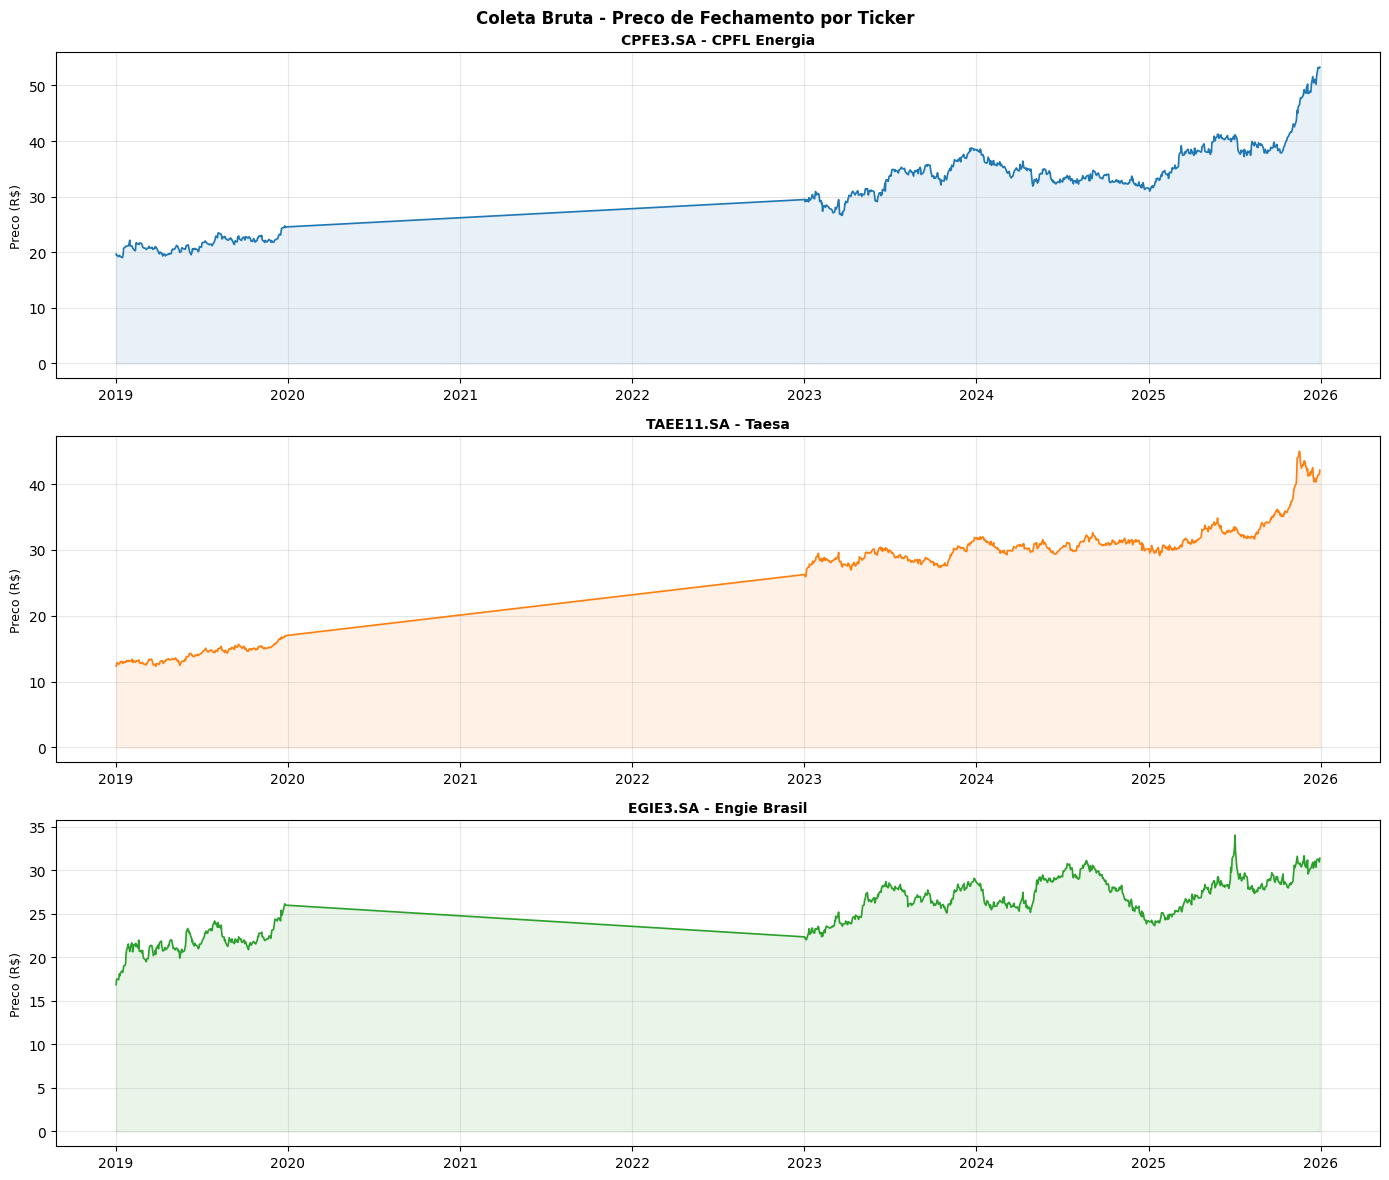

Coleta concluida.


In [3]:
TICKERS = ['CPFE3.SA', 'TAEE11.SA', 'EGIE3.SA']
NOMES = {
    'CPFE3.SA': 'CPFL Energia',
    'TAEE11.SA': 'Taesa',
    'EGIE3.SA': 'Engie Brasil',
}
CORES = {'CPFE3.SA': '#1f77b4', 'TAEE11.SA': '#ff7f0e', 'EGIE3.SA': '#2ca02c'}

PERIODOS = [
    ('2019-01-01', '2019-12-31'),
    ('2023-01-01', '2026-01-01'),  # end exclusivo no yfinance
 ]


def download_raw_blocks(ticker: str) -> pd.DataFrame:
    frames = []
    for start, end in PERIODOS:
        df_dl = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if not df_dl.empty:
            frames.append(df_dl)
    if not frames:
        return pd.DataFrame()

    df = pd.concat(frames).sort_index()
    df = df[(df.index.year == 2019) | (df.index.year >= 2023)]
    return df


def resumo_pregoes_por_ano(df: pd.DataFrame) -> pd.Series:
    return df.groupby(df.index.year).size().sort_index()


print('Coletando dados brutos por ticker...')
raw_dfs = {}
for ticker in TICKERS:
    raw = download_raw_blocks(ticker)
    if raw.empty:
        raise ValueError(f'{ticker}: sem dados no periodo definido.')
    raw_dfs[ticker] = raw

    anos = sorted(raw.index.year.unique().tolist())
    print(
        f"{ticker}: {raw.index.min().date()} -> {raw.index.max().date()} | "
        f"{len(raw)} pregoes | anos={anos}"
    )
    print(f"  Pregoes por ano: {resumo_pregoes_por_ano(raw).to_dict()}")

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 4 * len(TICKERS)))
if len(TICKERS) == 1:
    axes = [axes]

fig.suptitle('Coleta Bruta - Preco de Fechamento por Ticker', fontsize=12, fontweight='bold')
for ax, ticker in zip(axes, TICKERS):
    close_s = raw_dfs[ticker]['Close'].squeeze()
    ax.plot(close_s.index, close_s.values, color=CORES[ticker], lw=1.2)
    ax.fill_between(close_s.index, close_s.values, alpha=0.10, color=CORES[ticker])
    ax.set_title(f"{ticker} - {NOMES[ticker]}", fontsize=10, fontweight='bold')
    ax.set_ylabel('Preco (R$)', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Coleta concluida.')

In [4]:
FINAL_FEATURES = {
    'CPFE3.SA': [
        'Open', 'Volume', 'RSI_14', 'ROC_10', 'MACD_12_26_9',
        'BBB_20_2.0_2.0', 'ATR_14', 'STOCHk_14_3_3', 'ADX_14',
        'DMP_14', 'DMN_14', 'CCI_20', 'OBV',
    ],
    'TAEE11.SA': [
        'Open', 'Volume', 'RSI_14', 'MACD_12_26_9', 'BBB_20_2.0_2.0',
        'ATR_14', 'STOCHk_14_3_3', 'OBV',
    ],
    'EGIE3.SA': [
        'LogRet_1d', 'MACDh_12_26_9', 'STOCHk_14_3_3', 'STOCHh_14_3_3',
        'DMN_14', 'CCI_20',
    ],
}

# Alvo principal configurado para t+5.
TARGET_HORIZONS = [1, 3, 5]
PRIMARY_HORIZON = 5
USE_MULTI_HORIZON = False
TARGET_COL = f'Target_t+{PRIMARY_HORIZON}'


def build_required_features(df: pd.DataFrame) -> pd.DataFrame:
    close = df['Close'].squeeze().astype(float)
    high = df['High'].squeeze().astype(float)
    low = df['Low'].squeeze().astype(float)
    open_ = df['Open'].squeeze().astype(float)
    volume = df['Volume'].squeeze().astype(float)

    out = pd.DataFrame(index=df.index)
    out['Open'] = open_
    out['Volume'] = volume
    out['LogRet_1d'] = np.log(close).diff()
    out['ROC_10'] = ta.roc(close, length=10)
    out['RSI_14'] = ta.rsi(close, length=14)

    macd = ta.macd(close, fast=12, slow=26, signal=9)
    if macd is not None:
        out = out.join(macd)

    bb = ta.bbands(close, length=20, std=2.0)
    if bb is not None:
        out = out.join(bb)

    # Alias de compatibilidade entre versoes do pandas-ta
    if 'BBB_20_2.0_2.0' not in out.columns and 'BBB_20_2.0' in out.columns:
        out['BBB_20_2.0_2.0'] = out['BBB_20_2.0']

    out['ATR_14'] = ta.atr(high, low, close, length=14)

    stoch = ta.stoch(high, low, close, k=14, d=3, smooth_k=3)
    if stoch is not None:
        out = out.join(stoch)

    adx = ta.adx(high, low, close, length=14)
    if adx is not None:
        out = out.join(adx)

    out['CCI_20'] = ta.cci(high, low, close, length=20)
    out['OBV'] = ta.obv(close, volume)
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


def add_horizon_targets(logret_1d: pd.Series, horizons: list[int]) -> pd.DataFrame:
    """Cria colunas de alvo com retorno acumulado em cada horizonte."""
    out = pd.DataFrame(index=logret_1d.index)
    for h in horizons:
        # Soma de log-retornos futuros: [t+1, ..., t+h]
        out[f'Target_t+{h}'] = logret_1d.shift(-1).rolling(window=h).sum().shift(-(h - 1))
    return out


print('Aplicando selecao fixa de features e target por ticker...')
print(f'Alvo principal: {TARGET_COL} | Multi-horizonte ativo: {USE_MULTI_HORIZON}')
datasets_mi_filtered = {}

for ticker in TICKERS:
    feat = build_required_features(raw_dfs[ticker])

    missing_cols = [c for c in FINAL_FEATURES[ticker] if c not in feat.columns]
    if missing_cols:
        raise ValueError(f'{ticker}: colunas finais ausentes apos coleta: {missing_cols}')

    final_df = feat[FINAL_FEATURES[ticker]].copy()
    target_df = add_horizon_targets(feat['LogRet_1d'], TARGET_HORIZONS)
    final_df = final_df.join(target_df)

    active_target_cols = [f'Target_t+{h}' for h in TARGET_HORIZONS] if USE_MULTI_HORIZON else [TARGET_COL]
    keep_cols = FINAL_FEATURES[ticker] + active_target_cols
    final_df = final_df[keep_cols].dropna().copy()

    datasets_mi_filtered[ticker] = final_df
    print(
        f"{ticker}: final={len(final_df)} linhas | "
        f"preditores={len(FINAL_FEATURES[ticker])} | alvos={active_target_cols}"
    )

print('\nConjunto final carregado com sucesso.')

Aplicando selecao fixa de features e target por ticker...
Alvo principal: Target_t+5 | Multi-horizonte ativo: False
CPFE3.SA: final=967 linhas | preditores=13 | alvos=['Target_t+5']
TAEE11.SA: final=967 linhas | preditores=8 | alvos=['Target_t+5']
EGIE3.SA: final=959 linhas | preditores=6 | alvos=['Target_t+5']

Conjunto final carregado com sucesso.


# LSTM - Pipeline de Modelagem

## Estratégia de Split e Configuração Global

Split temporal:
- Treino: anos configuráveis via `TRAIN_SCENARIO` (`A_full` ou `B_recent`).
- Holdout final: 2025 (intocável para tuning).

Validação de hiperparâmetros:
- Walk-forward purgado em blocos temporais de 2024.
- Embargo (`PURGE_STEPS`) para reduzir leakage entre treino e validação.

Escalonamento:
- `StandardScaler` como padrão, por maior robustez em extrapolações fora da faixa de treino.
- `MinMaxScaler` mantido como opção de comparação.

In [5]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -- Flags globais ------------------------------------------------------------
SCALER_TYPE = 'standard'   # 'standard' | 'minmax'
N_PASSOS = 90
HOLDOUT_YEAR = 2025
BATCH_SIZE = 32
TRAIN_SEED = 42

# Comparativo de regime de treino.
TRAIN_SCENARIO = 'A_full'  # 'A_full' (2019+2023+2024) | 'B_recent' (2023+2024)
TRAIN_SCENARIO_YEARS = {
    'A_full': [2019, 2023, 2024],
    'B_recent': [2023, 2024],
}
ACTIVE_TRAIN_YEARS = TRAIN_SCENARIO_YEARS[TRAIN_SCENARIO]

# Treinamento com maior estabilidade.
GRAD_CLIP_NORM = 0.5
USE_LR_SCHEDULER = True
SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 8
SCHEDULER_MIN_LR = 1e-6

def make_scaler(scaler_type: str):
    if scaler_type == 'standard':
        return StandardScaler()
    elif scaler_type == 'minmax':
        return MinMaxScaler(feature_range=(0, 1))
    raise ValueError(f'Scaler desconhecido: {scaler_type}')


def set_global_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed(TRAIN_SEED)
print(f'Scaler selecionado     : {SCALER_TYPE}')
print(f'N_PASSOS               : {N_PASSOS}')
print(f'Holdout                : {HOLDOUT_YEAR}')
print(f'BATCH_SIZE             : {BATCH_SIZE}')
print(f'Train scenario         : {TRAIN_SCENARIO} -> anos={ACTIVE_TRAIN_YEARS}')
print(f'Grad clip              : {GRAD_CLIP_NORM}')
print(f'LR scheduler ativo     : {USE_LR_SCHEDULER}')

Scaler selecionado     : standard
N_PASSOS               : 90
Holdout                : 2025
BATCH_SIZE             : 32
Train scenario         : A_full -> anos=[2019, 2023, 2024]
Grad clip              : 0.5
LR scheduler ativo     : True


## Criação das Sequências com Máscara Temporal

As janelas usam `N_PASSOS=90` e causalidade estrita (apenas informações passadas).

Saídas desta etapa:
- `X`: janelas por ticker.
- `y`: alvo ativo (`Target_t+5`, com suporte a multi-horizonte).
- Datas alinhadas entre os tickers para treino conjunto da carteira.

In [6]:
def create_sequences_from_df(df_final: pd.DataFrame,
                              close_anchor: pd.Series,
                              n_passos: int,
                              target_cols: list[str]):
    """
    Cria janelas sequenciais com causalidade estrita.
    Retorna X, y, anchors de preco e datas-alvo (para alinhamento entre tickers).
    """
    feature_cols = [c for c in df_final.columns if not c.startswith('Target_t+')]
    X_np = df_final[feature_cols].values.astype(np.float64)
    y_np = df_final[target_cols].values.astype(np.float64)
    dates = df_final.index

    X, y, anchors, target_dates = [], [], [], []
    for i in range(n_passos, len(df_final)):
        window = X_np[i - n_passos:i, :]
        y_row = y_np[i]
        if not np.isfinite(window).all() or not np.isfinite(y_row).all():
            continue
        anchor = float(close_anchor.iloc[i])
        if anchor <= 0 or not np.isfinite(anchor):
            continue
        X.append(window)
        y.append(y_row if len(target_cols) > 1 else float(y_row[0]))
        anchors.append(anchor)
        target_dates.append(dates[i])

    y_arr = np.array(y, dtype=np.float32)
    return (
        np.array(X, dtype=np.float32),
        y_arr,
        np.array(anchors, dtype=np.float32),
        pd.DatetimeIndex(target_dates),
        feature_cols,
    )


def build_full_dataset(scaler_type: str = 'standard', train_years: list[int] | None = None):
    """
    ConstrÃ³i sequencias para todos os tickers, com:
    - Scaler fitado APENAS nas linhas de treino.
    - Split estratificado por datas alinhadas (intersecao dos tres tickers).
    - Retorna dict com X/y por ticker indexados por split (train/test).
    """
    train_years = train_years or ACTIVE_TRAIN_YEARS
    print('Construindo sequencias com split temporal customizavel...')
    print(f'Alvo em uso: {TARGET_COL} | multi-horizonte: {USE_MULTI_HORIZON}')
    print(f'Anos de treino: {train_years} | holdout: {HOLDOUT_YEAR}')
    print('=' * 80)

    all_sequences = {}

    for ticker in TICKERS:
        df_full = datasets_mi_filtered[ticker].copy().sort_index()
        feature_cols = [c for c in df_full.columns if not c.startswith('Target_t+')]
        available_targets = [c for c in df_full.columns if c.startswith('Target_t+')]
        target_cols = sorted(available_targets, key=lambda s: int(s.split('+')[1]))
        if TARGET_COL not in target_cols:
            raise ValueError(f'{ticker}: alvo principal {TARGET_COL} ausente em df_final.')
        if not USE_MULTI_HORIZON:
            target_cols = [TARGET_COL]

        n_feat = len(feature_cols)
        train_mask = df_full.index.year.isin(train_years)

        sc = make_scaler(scaler_type)
        sc.fit(df_full.loc[train_mask, feature_cols])

        df_scaled = df_full.copy()
        df_scaled.loc[:, feature_cols] = sc.transform(df_scaled[feature_cols])

        close_anchor = raw_dfs[ticker]['Close'].squeeze().reindex(df_scaled.index).ffill().bfill()
        X, y, anchors, dates, fcols = create_sequences_from_df(
            df_scaled, close_anchor, N_PASSOS, target_cols
        )

        all_sequences[ticker] = {
            'X': X, 'y': y, 'anchors': anchors, 'dates': dates,
            'feature_cols': fcols, 'target_cols': target_cols,
            'n_features': n_feat, 'scaler': sc,
        }

    common_dates = None
    for ticker in TICKERS:
        d = set(all_sequences[ticker]['dates'])
        common_dates = d if common_dates is None else common_dates & d
    common_dates = sorted(common_dates)
    common_idx = pd.DatetimeIndex(common_dates)

    print(f'Datas comuns (alinhadas): {len(common_idx)} sequencias')

    mask_train = common_idx.year.isin(train_years)
    mask_test = common_idx.year == HOLDOUT_YEAR

    datasets_aligned = {}
    for ticker in TICKERS:
        seq = all_sequences[ticker]
        loc_map = {d: i for i, d in enumerate(seq['dates'])}
        common_locs = np.array([loc_map[d] for d in common_dates])

        X = seq['X'][common_locs]
        y = seq['y'][common_locs]
        anc = seq['anchors'][common_locs]

        datasets_aligned[ticker] = {
            'X_train': X[mask_train], 'y_train': y[mask_train], 'anc_train': anc[mask_train],
            'X_test': X[mask_test], 'y_test': y[mask_test], 'anc_test': anc[mask_test],
            'n_features': seq['n_features'],
            'feature_cols': seq['feature_cols'],
            'target_cols': seq['target_cols'],
            'scaler': seq['scaler'],
            'dates_train': common_idx[mask_train],
            'dates_test': common_idx[mask_test],
        }

        ln_ratio = N_PASSOS / seq['n_features']
        print(f"\n{ticker} | features={seq['n_features']} | L/N={ln_ratio:.2f}")
        print(f"  train({train_years}) : {mask_train.sum():>4} seq")
        print(f"  holdout {HOLDOUT_YEAR}       : {mask_test.sum():>4} seq")

    return datasets_aligned


datasets_aligned = build_full_dataset(SCALER_TYPE, ACTIVE_TRAIN_YEARS)
print()
print('Dataset alinhado construido com sucesso.')

Construindo sequencias com split temporal customizavel...
Alvo em uso: Target_t+5 | multi-horizonte: False
Anos de treino: [2019, 2023, 2024] | holdout: 2025
Datas comuns (alinhadas): 869 sequencias

CPFE3.SA | features=13 | L/N=6.92
  train([2019, 2023, 2024]) :  624 seq
  holdout 2025       :  245 seq

TAEE11.SA | features=8 | L/N=11.25
  train([2019, 2023, 2024]) :  624 seq
  holdout 2025       :  245 seq

EGIE3.SA | features=6 | L/N=15.00
  train([2019, 2023, 2024]) :  624 seq
  holdout 2025       :  245 seq

Dataset alinhado construido com sucesso.


## PortfolioDataset e DataLoaders

A carteira é treinada com batches sincronizados entre os 3 tickers.
`shuffle=False` é obrigatório para preservar a ordem temporal e o alinhamento.

Esta célula também constrói:
- Loader de treino completo.
- Loader de holdout.
- Folds walk-forward com purging.

In [7]:
class PortfolioDataset(Dataset):
    """Dataset conjunto: cada item e um dicionario com X de todos os tickers."""
    def __init__(self, data_dict: dict, split: str):
        # data_dict: {ticker: datasets_aligned[ticker]}
        # split: 'train' | 'test'
        self.tickers = list(data_dict.keys())
        self.X = {t: torch.tensor(data_dict[t][f'X_{split}'], dtype=torch.float32)
                  for t in self.tickers}
        self.y = {t: torch.tensor(data_dict[t][f'y_{split}'], dtype=torch.float32)
                  for t in self.tickers}
        self.n = len(self.X[self.tickers[0]])
        # Verificacao de alinhamento
        for t in self.tickers:
            assert len(self.X[t]) == self.n, f'Desalinhamento em {t}: {len(self.X[t])} != {self.n}'

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return (
            {t: self.X[t][idx] for t in self.tickers},
            {t: self.y[t][idx] for t in self.tickers},
        )


def make_loaders(data: dict, split: str, batch_size: int = BATCH_SIZE) -> DataLoader:
    ds = PortfolioDataset(data, split)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)


N_WF_FOLDS = 4
PURGE_STEPS = N_PASSOS


def build_purged_walk_forward_splits(
    train_dates: pd.DatetimeIndex,
    n_folds: int = N_WF_FOLDS,
    purge_steps: int = PURGE_STEPS,
    val_year: int = 2024,
    min_train_size: int = 150,
    min_val_size: int = 20,
 ) -> list[dict]:
    """
    Gera folds walk-forward por blocos temporais em `val_year` com embargo (purging).
    A validacao e sempre posterior ao treino e ha gap de `purge_steps` observacoes.
    """
    val_pos = np.where(train_dates.year == val_year)[0]
    if len(val_pos) == 0:
        raise ValueError(f'Nenhuma data de validacao encontrada para val_year={val_year}.')

    raw_blocks = [blk for blk in np.array_split(val_pos, n_folds) if len(blk) > 0]
    splits = []
    for fold_num, val_idx in enumerate(raw_blocks, start=1):
        val_start = int(val_idx[0])
        train_end_exclusive = val_start - purge_steps
        if train_end_exclusive <= 0:
            continue

        train_idx = np.arange(0, train_end_exclusive)
        if len(train_idx) < min_train_size or len(val_idx) < min_val_size:
            continue

        splits.append({
            'fold': fold_num,
            'train_idx': train_idx,
            'val_idx': val_idx,
            'val_start': train_dates[val_idx[0]],
            'val_end': train_dates[val_idx[-1]],
        })

    if len(splits) < 2:
        raise ValueError(
            f'Poucos folds validos apos purging: {len(splits)}. '
            'Ajuste n_folds/purge_steps/min_train_size.'
        )
    return splits


class FoldDataset(Dataset):
    def __init__(self, data_dict: dict, split_key: str, indices: np.ndarray):
        self.tickers = list(data_dict.keys())
        self.X = {
            t: torch.tensor(data_dict[t][f'X_{split_key}'][indices], dtype=torch.float32)
            for t in self.tickers
        }
        self.y = {
            t: torch.tensor(data_dict[t][f'y_{split_key}'][indices], dtype=torch.float32)
            for t in self.tickers
        }
        self.n = len(self.X[self.tickers[0]])

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return ({t: self.X[t][idx] for t in self.tickers},
                {t: self.y[t][idx] for t in self.tickers})


def make_fold_loaders(data: dict, split_cfg: dict) -> tuple[DataLoader, DataLoader]:
    """Constroi loaders de um fold ja purgado."""
    tr_ds = FoldDataset(data, 'train', split_cfg['train_idx'])
    va_ds = FoldDataset(data, 'train', split_cfg['val_idx'])
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=False)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False)
    return tr_loader, va_loader


# Loaders finais (treino ativo + holdout 2025)
loader_train_full = make_loaders(datasets_aligned, 'train')
loader_test = make_loaders(datasets_aligned, 'test')

WF_SPLITS = build_purged_walk_forward_splits(
    train_dates=datasets_aligned[TICKERS[0]]['dates_train'],
    n_folds=N_WF_FOLDS,
    purge_steps=PURGE_STEPS,
    val_year=2024,
    min_train_size=150,
    min_val_size=20,
 )

print('DataLoaders construidos (shuffle=False em todos):')
for split, loader in [('Treino completo', loader_train_full), ('Holdout 2025', loader_test)]:
    print(f'  {split}: {len(loader.dataset)} sequencias | {len(loader)} batches')

print(f'\nWalk-forward purgado: {len(WF_SPLITS)} folds validos | purge={PURGE_STEPS} passos')
for s in WF_SPLITS:
    tr_l, va_l = make_fold_loaders(datasets_aligned, s)
    print(
        f"  Fold {s['fold']}: treino={len(tr_l.dataset)} seq | val={len(va_l.dataset)} seq "
        f"| janela val={s['val_start'].date()} -> {s['val_end'].date()}"
    )

DataLoaders construidos (shuffle=False em todos):
  Treino completo: 624 sequencias | 20 batches
  Holdout 2025: 245 sequencias | 8 batches

Walk-forward purgado: 4 folds validos | purge=90 passos
  Fold 1: treino=283 seq | val=63 seq | janela val=2024-01-02 -> 2024-04-02
  Fold 2: treino=346 seq | val=63 seq | janela val=2024-04-03 -> 2024-07-02
  Fold 3: treino=409 seq | val=63 seq | janela val=2024-07-03 -> 2024-09-27
  Fold 4: treino=472 seq | val=62 seq | janela val=2024-09-30 -> 2024-12-30


## Arquitetura: PortfolioLSTM

A arquitetura foi mantida compacta para reduzir risco de sobreajuste:
- 1 encoder LSTM por ticker.
- Cabeça conjunta para capturar co-movimento setorial.
- Dropout na representação e na cabeça final.

A contagem de parâmetros e a razão params/seq são exibidas abaixo para controle de complexidade.

In [8]:
class PortfolioLSTM(nn.Module):
    """
    LSTM multi-output para carteira de 3 ativos.

    Arquitetura:
      - Encoder LSTM separado por ticker (features de entrada diferem entre tickers)
      - Dropout aplicado na saÃ­da de cada encoder
      - CabeÃ§a conjunta: concatena as 3 representaÃ§Ãµes ocultas e prevÃª 3 retornos simultÃ¢neos

    O design conjunto permite que a previsÃ£o de cada ativo incorpore informaÃ§Ã£o
    das representaÃ§Ãµes latentes dos outros, capturando co-movimentos setoriais.
    """
    def __init__(self,
                 input_sizes: dict,          # {ticker: n_features}
                 hidden_size: int   = 16,
                 num_layers: int    = 1,
                 dropout: float     = 0.3):
        super().__init__()
        self.tickers     = list(input_sizes.keys())
        self.hidden_size = hidden_size

        self.encoders = nn.ModuleDict({
            t.replace('.', '_'): nn.LSTM(
                input_size  = input_sizes[t],
                hidden_size = hidden_size,
                num_layers  = num_layers,
                dropout     = dropout if num_layers > 1 else 0.0,
                batch_first = True,
            ) for t in self.tickers
        })

        self.enc_dropout = nn.Dropout(p=dropout)

        joint_input = hidden_size * len(self.tickers)
        self.joint_head = nn.Sequential(
            nn.Linear(joint_input, hidden_size),
            nn.Tanh(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_size, len(self.tickers)),
        )

    def forward(self, x_dict: dict) -> torch.Tensor:
        """
        x_dict: {ticker: tensor(batch, seq, features)}
        Returns: tensor(batch, n_tickers)
        """
        reps = []
        for t in self.tickers:
            key  = t.replace('.', '_')
            out, _ = self.encoders[key](x_dict[t])
            reps.append(self.enc_dropout(out[:, -1, :]))
        joint = torch.cat(reps, dim=-1)   # (batch, n_tickers * hidden)
        return self.joint_head(joint)     # (batch, n_tickers)

    def n_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def build_model(hidden_size=16, num_layers=1, dropout=0.3) -> PortfolioLSTM:
    input_sizes = {t: datasets_aligned[t]['n_features'] for t in TICKERS}
    return PortfolioLSTM(input_sizes, hidden_size, num_layers, dropout).to(DEVICE)


# â”€â”€ Contagem de parÃ¢metros â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
model_check = build_model()
n_params = model_check.n_params()
n_train_seq = len(loader_train_full.dataset)
print(f'PortfolioLSTM â€” parÃ¢metros treinÃ¡veis : {n_params:,}')
print(f'SequÃªncias de treino (2019+2023+2024) : {n_train_seq}')
print(f'Ratio params/seq                      : {n_params / n_train_seq:.1f}')
print()
print('Arquitetura:')
print(model_check)
del model_check


PortfolioLSTM â€” parÃ¢metros treinÃ¡veis : 6,019
SequÃªncias de treino (2019+2023+2024) : 624
Ratio params/seq                      : 9.6

Arquitetura:
PortfolioLSTM(
  (encoders): ModuleDict(
    (CPFE3_SA): LSTM(13, 16, batch_first=True)
    (TAEE11_SA): LSTM(8, 16, batch_first=True)
    (EGIE3_SA): LSTM(6, 16, batch_first=True)
  )
  (enc_dropout): Dropout(p=0.3, inplace=False)
  (joint_head): Sequential(
    (0): Linear(in_features=48, out_features=16, bias=True)
    (1): Tanh()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=3, bias=True)
  )
)


## Loop de Treinamento

Treino com regularização e parada adaptativa:
- Otimizador `AdamW`.
- `ReduceLROnPlateau` opcional para refino do learning rate.
- `EarlyStopping` para interromper o treino em platô de validação.
- `gradient clipping` controlado por `GRAD_CLIP_NORM`.

Objetivo: aumentar a estabilidade de convergência sem inflar a complexidade da rede.

In [9]:
class EarlyStopping:
    """Para o treino quando val_loss nao melhora por `patience` epocas consecutivas."""
    def __init__(self, patience: int = 15, min_delta: float = 1e-7):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None
        self.stopped_at = None

    def step(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.stopped_at = epoch
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_portfolio_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    hidden_size: int = 16,
    num_layers: int = 1,
    dropout: float = 0.3,
    lr: float = 1e-3,
    weight_decay: float = 1e-3,
    max_epochs: int = 300,
    patience: int = 20,
    seed: int = TRAIN_SEED,
    verbose: bool = True,
    clip_norm: float = GRAD_CLIP_NORM,
    use_scheduler: bool = USE_LR_SCHEDULER,
    scheduler_factor: float = SCHEDULER_FACTOR,
    scheduler_patience: int = SCHEDULER_PATIENCE,
    scheduler_min_lr: float = SCHEDULER_MIN_LR,
 ) -> tuple[PortfolioLSTM, dict, EarlyStopping]:
    """
    Treina PortfolioLSTM com early stopping + scheduler opcional.
    """
    set_global_seed(seed)
    model = build_model(hidden_size, num_layers, dropout)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=scheduler_min_lr
        )

    es = EarlyStopping(patience=patience)
    history = {'train': [], 'val': [], 'lr': []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_total, tr_n = 0.0, 0
        for X_batch, y_batch in train_loader:
            X_b = {t: X_batch[t].to(DEVICE) for t in TICKERS}
            y_b = torch.stack([y_batch[t].to(DEVICE) for t in TICKERS], dim=1)
            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
            optimizer.step()
            tr_total += loss.item() * len(y_b)
            tr_n += len(y_b)
        train_loss = tr_total / tr_n

        model.eval()
        va_total, va_n = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_b = {t: X_batch[t].to(DEVICE) for t in TICKERS}
                y_b = torch.stack([y_batch[t].to(DEVICE) for t in TICKERS], dim=1)
                preds = model(X_b)
                va_total += criterion(preds, y_b).item() * len(y_b)
                va_n += len(y_b)
        val_loss = va_total / va_n

        if scheduler is not None:
            scheduler.step(val_loss)

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if es.step(val_loss, model, epoch):
            if verbose:
                print(
                    f'  Early stopping na epoca {epoch} | melhor val_loss={es.best_loss:.6f} '
                    f'(epoca {es.stopped_at})'
                )
            break

    es.restore_best(model)
    return model, history, es


print('Funcoes de treinamento atualizadas (AdamW + ReduceLROnPlateau + clip=0.5).')

Funcoes de treinamento atualizadas (AdamW + ReduceLROnPlateau + clip=0.5).


## Walk-Forward Cross-Validation

O tuning é realizado com folds temporais purgados para evitar leakage.
A grade de hiperparâmetros é pequena e controlada para reduzir custo e risco de sobreajuste na seleção.

O critério principal permanece sendo a `val_loss` média entre os folds.

In [10]:
HP_GRID = [
    {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3, 'weight_decay': 1e-3},
    {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'lr': 1e-3, 'weight_decay': 1e-3},
    {'hidden_size': 24, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3, 'weight_decay': 1e-3},
    {'hidden_size': 24, 'num_layers': 1, 'dropout': 0.3, 'lr': 1e-3, 'weight_decay': 1e-3},
]

wf_results = []

print(f'Walk-Forward CV purgado - {len(WF_SPLITS)} folds x {len(HP_GRID)} configuracoes')
print('=' * 80)

for cfg in HP_GRID:
    fold_val_losses = []

    for split_cfg in WF_SPLITS:
        tr_loader, va_loader = make_fold_loaders(datasets_aligned, split_cfg)

        _, _, es = train_portfolio_model(
            train_loader=tr_loader,
            val_loader=va_loader,
            **cfg,
            max_epochs=300,
            patience=20,
            seed=TRAIN_SEED,
            verbose=False,
        )
        fold_val_losses.append(es.best_loss)

    mean_val = float(np.mean(fold_val_losses))
    wf_results.append({
        **cfg,
        'fold_losses': fold_val_losses,
        'mean_val': mean_val,
    })

    n_p = build_model(cfg['hidden_size'], cfg['num_layers'], cfg['dropout']).n_params()
    fold_msg = ' | '.join([f"f{i + 1}={v:.6f}" for i, v in enumerate(fold_val_losses)])
    print(
        f"h={cfg['hidden_size']:>2} | layers={cfg['num_layers']} | drop={cfg['dropout']} | "
        f"{fold_msg} | mean={mean_val:.6f} | params={n_p}"
    )

# Melhor configuracao
best_cfg = min(wf_results, key=lambda x: x['mean_val'])
BEST_HP = {k: v for k, v in best_cfg.items() if k in HP_GRID[0]}
print()
print('Melhor configuracao (menor val_loss medio):')
for k, v in BEST_HP.items():
    print(f'  {k}: {v}')
print(f"  fold_losses: {[round(v, 6) for v in best_cfg['fold_losses']]}")

Walk-Forward CV purgado - 4 folds x 4 configuracoes
h=16 | layers=1 | drop=0.2 | f1=0.000701 | f2=0.000974 | f3=0.000546 | f4=0.000532 | mean=0.000688 | params=6019
h=16 | layers=1 | drop=0.3 | f1=0.000636 | f2=0.000809 | f3=0.000403 | f4=0.000494 | mean=0.000586 | params=6019
h=24 | layers=1 | drop=0.2 | f1=0.001092 | f2=0.000839 | f3=0.000570 | f4=0.000807 | mean=0.000827 | params=11907
h=24 | layers=1 | drop=0.3 | f1=0.000916 | f2=0.000714 | f3=0.000523 | f4=0.000630 | mean=0.000696 | params=11907

Melhor configuracao (menor val_loss medio):
  hidden_size: 16
  num_layers: 1
  dropout: 0.3
  lr: 0.001
  weight_decay: 0.001
  fold_losses: [0.000636, 0.000809, 0.000403, 0.000494]


## Treinamento Final e Holdout

Após o tuning, o modelo final é treinado no conjunto de treino ativo.
O holdout de 2025 é usado apenas nesta etapa para mensuração final.

Treinamento final: PortfolioLSTM no cenario ativo...
HiperparÃ¢metros: {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.001}

  Early stopping na epoca 64 | melhor val_loss=0.000908 (epoca 34)

ParÃ¢metros do modelo final : 6,019
Melhor Ã©poca (early stop)  : 34
Melhor val_loss (holdout)  : 0.000908


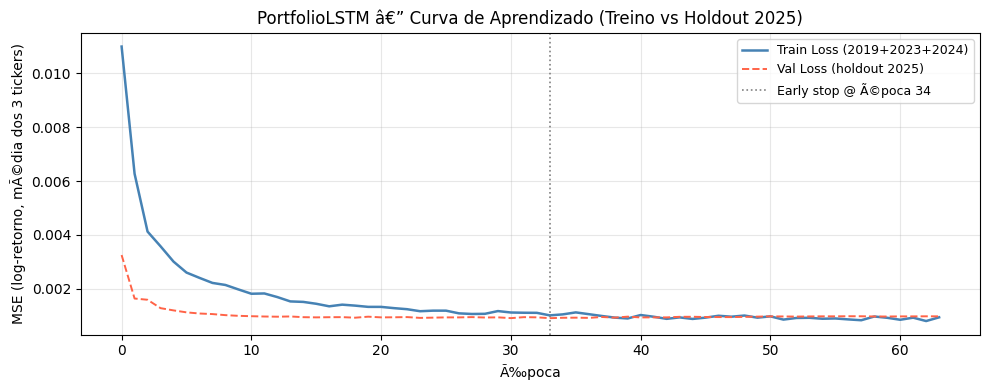


DiagnÃ³stico de assimetria de regime (volatilidade por split):
------------------------------------------------------------
  CPFE3.SA: std_train=0.03101 | std_test=0.02667 | ratio=1.16 âœ“ regimes similares
  TAEE11.SA: std_train=0.04383 | std_test=0.02535 | ratio=1.73 âš  regime diferente
  EGIE3.SA: std_train=0.02872 | std_test=0.03051 | ratio=0.94 âœ“ regimes similares

Nota: se std_train >> std_test, val_loss < train_loss Ã© artefato de regime, nÃ£o generalizaÃ§Ã£o.


In [11]:
print('Treinamento final: PortfolioLSTM no cenario ativo...')
print('=' * 80)
print(f'HiperparÃ¢metros: {BEST_HP}')
print()

final_model, final_history, final_es = train_portfolio_model(
    train_loader = loader_train_full,
    val_loader   = loader_test,          # monitorar val_loss no holdout (sem uso para seleÃ§Ã£o)
    **BEST_HP,
    max_epochs   = 400,
    patience     = 30,
    seed         = TRAIN_SEED,
    verbose      = True,
)

print(f'\nParÃ¢metros do modelo final : {final_model.n_params():,}')
print(f'Melhor Ã©poca (early stop)  : {final_es.stopped_at}')
print(f'Melhor val_loss (holdout)  : {final_es.best_loss:.6f}')

# â”€â”€ Curvas de aprendizado â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(final_history['train'], label='Train Loss (2019+2023+2024)', color='steelblue', lw=1.8)
ax.plot(final_history['val'],   label='Val Loss (holdout 2025)',     color='tomato',    lw=1.4, ls='--')
ax.axvline(final_es.stopped_at - 1, color='gray', ls=':', lw=1.2, label=f'Early stop @ Ã©poca {final_es.stopped_at}')
ax.set_title('PortfolioLSTM â€” Curva de Aprendizado (Treino vs Holdout 2025)')
ax.set_xlabel('Ã‰poca')
ax.set_ylabel('MSE (log-retorno, mÃ©dia dos 3 tickers)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# â”€â”€ DiagnÃ³stico de regime (assimetria de volatilidade) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print()
print('DiagnÃ³stico de assimetria de regime (volatilidade por split):')
print('-' * 60)
for ticker in TICKERS:
    d = datasets_aligned[ticker]
    std_train = d['y_train'].std()
    std_test  = d['y_test'].std()
    ratio     = std_train / (std_test + 1e-12)
    flag      = 'âš  regime diferente' if ratio > 1.3 or ratio < 0.7 else 'âœ“ regimes similares'
    print(f'  {ticker}: std_train={std_train:.5f} | std_test={std_test:.5f} | '
          f'ratio={ratio:.2f} {flag}')
print()
print('Nota: se std_train >> std_test, val_loss < train_loss Ã© artefato de regime, nÃ£o generalizaÃ§Ã£o.')


## Avaliação no Holdout 2025

A avaliação combina métricas estatísticas e financeiras:
- Erro e ajuste (`R2`, `RMSE`, `MAPE`).
- Utilidade de sinal (`Hit Rate` e `Sharpe do sinal`).
- Incerteza via MC Dropout (`N_MC`).

In [12]:
N_MC = 50
MC_SEEDS = [200 + i for i in range(N_MC)]

def predict_portfolio(model, loader, mc_dropout=False, seed=None):
    """
    Inferencia multi-output.
    Retorna dict {ticker: array de retornos previstos (horizonte alvo).}
    """
    if seed is not None:
        set_global_seed(seed)
    if mc_dropout:
        model.train()   # ativa dropout
    else:
        model.eval()

    all_preds = {t: [] for t in TICKERS}
    with torch.no_grad():
        for X_batch, _ in loader:
            X_b = {t: X_batch[t].to(DEVICE) for t in TICKERS}
            preds = model(X_b).cpu().numpy()   # (B, 3)
            for j, t in enumerate(TICKERS):
                all_preds[t].extend(preds[:, j])

    return {t: np.array(all_preds[t], dtype=np.float64) for t in TICKERS}


def directional_hit_rate(true_ret: np.ndarray, pred_ret: np.ndarray) -> float:
    """Percentual de acerto do sinal entre retorno real e previsto."""
    true_sign = np.sign(true_ret)
    pred_sign = np.sign(pred_ret)
    valid = np.isfinite(true_sign) & np.isfinite(pred_sign)
    if valid.sum() == 0:
        return np.nan
    return float((true_sign[valid] == pred_sign[valid]).mean())


def signal_sharpe_ratio(true_ret: np.ndarray, pred_ret: np.ndarray, annualization: int = 252) -> float:
    """
    Sharpe do sinal: retorno de estrategia simples sign(pred)*true.
    """
    signal = np.sign(pred_ret)
    strat_ret = signal * true_ret
    strat_ret = strat_ret[np.isfinite(strat_ret)]
    if len(strat_ret) < 2:
        return np.nan
    vol = strat_ret.std(ddof=1)
    if vol < 1e-12:
        return np.nan
    return float((strat_ret.mean() / vol) * np.sqrt(annualization))


def evaluate_holdout(preds_log: dict) -> pd.DataFrame:
    """Calcula metricas por ticker para o holdout 2025."""
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    rows = []
    for ticker in TICKERS:
        true_ret = datasets_aligned[ticker]['y_test'].astype(np.float64)
        pred_ret = preds_log[ticker][:len(true_ret)]
        anc = datasets_aligned[ticker]['anc_test'][:len(true_ret)].astype(np.float64)

        pred_price = anc * np.exp(pred_ret)
        true_price = anc * np.exp(true_ret)

        rows.append({
            'ticker': ticker,
            'r2_log': r2_score(true_ret, pred_ret),
            'rmse_price': np.sqrt(mean_squared_error(true_price, pred_price)),
            'mae_price': mean_absolute_error(true_price, pred_price),
            'mape_pct': np.mean(np.abs((true_price - pred_price) / (np.abs(true_price) + 1e-8))) * 100,
            'hit_rate': directional_hit_rate(true_ret, pred_ret),
            'sharpe_signal': signal_sharpe_ratio(true_ret, pred_ret),
        })
    return pd.DataFrame(rows)


# - Inferencia MC
print(f'Inferencia MC Dropout no holdout 2025 ({N_MC} runs)...')
mc_preds = {t: [] for t in TICKERS}
mc_metrics = []

for seed in MC_SEEDS:
    preds = predict_portfolio(final_model, loader_test, mc_dropout=True, seed=seed)
    df_m = evaluate_holdout(preds)
    df_m['seed'] = seed
    mc_metrics.append(df_m)
    for t in TICKERS:
        mc_preds[t].append(preds[t])

df_mc_all = pd.concat(mc_metrics, ignore_index=True)

# Sumario por ticker
summary = df_mc_all.groupby('ticker').agg(
    r2_mean=('r2_log', 'mean'), r2_std=('r2_log', 'std'),
    rmse_mean=('rmse_price', 'mean'), rmse_std=('rmse_price', 'std'),
    mape_mean=('mape_pct', 'mean'), mape_std=('mape_pct', 'std'),
    hit_mean=('hit_rate', 'mean'), hit_std=('hit_rate', 'std'),
    sharpe_mean=('sharpe_signal', 'mean'), sharpe_std=('sharpe_signal', 'std'),
).reset_index()

print()
print('Sumario das inferencias MC (holdout 2025):')
print(summary.to_string(index=False, float_format='%.4f'))

# - Incerteza preditiva ponto-a-ponto
pred_variance = {}
for t in TICKERS:
    mat = np.vstack(mc_preds[t])    # (N_MC, seq_len)
    pred_variance[t] = mat.var(axis=0, ddof=1)

print('\nVariancia preditiva media por ticker (2025):')
for t in TICKERS:
    print(f'  {t}: {pred_variance[t].mean():.2e}')

Inferencia MC Dropout no holdout 2025 (50 runs)...

Sumario das inferencias MC (holdout 2025):
   ticker  r2_mean  r2_std  rmse_mean  rmse_std  mape_mean  mape_std  hit_mean  hit_std  sharpe_mean  sharpe_std
 CPFE3.SA  -0.5292  0.0920     1.3407    0.0433     2.5451    0.0856    0.4807   0.0309      -0.9307      1.0340
 EGIE3.SA  -0.3732  0.0719     1.0338    0.0272     2.6271    0.0728    0.4727   0.0291      -0.6138      0.8093
TAEE11.SA  -0.7291  0.1370     1.2112    0.0487     2.5378    0.1089    0.4900   0.0304       0.4708      1.0816

Variancia preditiva media por ticker (2025):
  CPFE3.SA: 1.81e-04
  TAEE11.SA: 3.84e-04
  EGIE3.SA: 2.03e-04


## Relatório Consolidado

In [13]:
print('RELATORIO FINAL - PortfolioLSTM')
print('=' * 80)

print('\n[1] Configuracao do experimento:')
print(f'  Alvo principal     : {TARGET_COL}')
print(f'  Multi-horizonte    : {USE_MULTI_HORIZON} (horizons={TARGET_HORIZONS})')
print(f'  Scaler             : {SCALER_TYPE}')
print(f'  Arquitetura        : PortfolioLSTM (encoders separados + cabeca conjunta)')
print(f'  Parametros totais  : {final_model.n_params():,}')
print(f'  Train scenario     : {TRAIN_SCENARIO} -> anos={ACTIVE_TRAIN_YEARS}')
print(f'  Holdout            : 2025 (intocavel ate esta celula)')
print(f'  Early stopping em  : epoca {final_es.stopped_at} (patience={final_es.patience})')
print(f'  Hiperparametros    : {BEST_HP}')
print(f'  WF folds (purgado) : {len(WF_SPLITS)} | purge={PURGE_STEPS} passos')
print(f'  Optimizer          : AdamW')
print(f'  LR scheduler       : ReduceLROnPlateau={USE_LR_SCHEDULER}')
print(f'  Gradient clipping  : {GRAD_CLIP_NORM}')

print('\n[2] Qualidade de generalizacao (train vs holdout 2025):')
tr_loss_final = final_history['train'][final_es.stopped_at - 1]
va_loss_final = final_history['val'][final_es.stopped_at - 1]
gap_ratio = va_loss_final / (tr_loss_final + 1e-12)
print(f'  train_loss (epoca {final_es.stopped_at}): {tr_loss_final:.6f}')
print(f'  val_loss   (epoca {final_es.stopped_at}): {va_loss_final:.6f}')
print(f'  gap_ratio (val/train)      : {gap_ratio:.3f}')
print(f"  lr final monitorado        : {final_history['lr'][final_es.stopped_at - 1]:.2e}")
if gap_ratio < 0.85:
    print('  ATENCAO: val_loss < train_loss - checar assimetria de regime.')
elif gap_ratio <= 1.20:
    print('  Gap dentro do intervalo esperado.')
else:
    print('  ATENCAO: gap alto - possivel overfitting.')

print('\n[3] Metricas no holdout 2025 (media das inferencias MC):')
for _, row in summary.iterrows():
    print(
        f"  {row['ticker']}: R2={row['r2_mean']:+.4f}+/-{row['r2_std']:.4f} | "
        f"RMSE={row['rmse_mean']:.4f}+/-{row['rmse_std']:.4f} | "
        f"MAPE={row['mape_mean']:.3f}%+/-{row['mape_std']:.3f}% | "
        f"HitRate={row['hit_mean']:.3f}+/-{row['hit_std']:.3f} | "
        f"SharpeSinal={row['sharpe_mean']:.3f}+/-{row['sharpe_std']:.3f}"
    )

print('\n[4] Leitura tecnica consolidada:')
print('  - Prioridades medias implementadas: AdamW + ReduceLROnPlateau + clip=0.5.')
print('  - Trilha comparativa de regime habilitada via TRAIN_SCENARIO (A_full vs B_recent).')
print('  - Walk-forward purgado e metricas financeiras mantidos.')

RELATORIO FINAL - PortfolioLSTM

[1] Configuracao do experimento:
  Alvo principal     : Target_t+5
  Multi-horizonte    : False (horizons=[1, 3, 5])
  Scaler             : standard
  Arquitetura        : PortfolioLSTM (encoders separados + cabeca conjunta)
  Parametros totais  : 6,019
  Train scenario     : A_full -> anos=[2019, 2023, 2024]
  Holdout            : 2025 (intocavel ate esta celula)
  Early stopping em  : epoca 34 (patience=30)
  Hiperparametros    : {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.001}
  WF folds (purgado) : 4 | purge=90 passos
  Optimizer          : AdamW
  LR scheduler       : ReduceLROnPlateau=True
  Gradient clipping  : 0.5

[2] Qualidade de generalizacao (train vs holdout 2025):
  train_loss (epoca 34): 0.001012
  val_loss   (epoca 34): 0.000908
  gap_ratio (val/train)      : 0.898
  lr final monitorado        : 1.00e-03
  Gap dentro do intervalo esperado.

[3] Metricas no holdout 2025 (media das inferencias MC):
 

In [14]:
# Comparativo formal de regime: A_full vs B_recent
def run_regime_experiment(label: str, years: list[int], hp: dict):
    print(f"\n[{label}] Anos treino = {years}")
    backup = {
        'datasets_aligned': datasets_aligned,
        'loader_train_full': loader_train_full,
        'loader_test': loader_test,
        'WF_SPLITS': WF_SPLITS,
    }

    try:
        local_data = build_full_dataset(SCALER_TYPE, years)
        local_loader_train = make_loaders(local_data, 'train')
        local_loader_test = make_loaders(local_data, 'test')
        local_splits = build_purged_walk_forward_splits(
            train_dates=local_data[TICKERS[0]]['dates_train'],
            n_folds=N_WF_FOLDS,
            purge_steps=PURGE_STEPS,
            val_year=2024,
            min_train_size=120,
            min_val_size=20,
        )

        globals()['datasets_aligned'] = local_data
        globals()['loader_train_full'] = local_loader_train
        globals()['loader_test'] = local_loader_test
        globals()['WF_SPLITS'] = local_splits

        model, history, es = train_portfolio_model(
            train_loader=loader_train_full,
            val_loader=loader_test,
            **hp,
            max_epochs=260,
            patience=25,
            seed=TRAIN_SEED,
            verbose=False,
        )

        preds = predict_portfolio(model, loader_test, mc_dropout=False, seed=TRAIN_SEED)
        df_eval = evaluate_holdout(preds)

        out = {
            'scenario': label,
            'years': years,
            'n_train_seq': len(loader_train_full.dataset),
            'n_test_seq': len(loader_test.dataset),
            'best_epoch': es.stopped_at,
            'best_val_loss': es.best_loss,
            'r2_mean': float(df_eval['r2_log'].mean()),
            'hit_mean': float(df_eval['hit_rate'].mean()),
            'sharpe_mean': float(df_eval['sharpe_signal'].mean()),
        }
        return out, df_eval

    finally:
        globals()['datasets_aligned'] = backup['datasets_aligned']
        globals()['loader_train_full'] = backup['loader_train_full']
        globals()['loader_test'] = backup['loader_test']
        globals()['WF_SPLITS'] = backup['WF_SPLITS']


HP_REGIME = BEST_HP.copy()
res_full, eval_full = run_regime_experiment('A_full', [2019, 2023, 2024], HP_REGIME)
res_recent, eval_recent = run_regime_experiment('B_recent', [2023, 2024], HP_REGIME)

df_regime_compare = pd.DataFrame([res_full, res_recent])
print('\nComparativo de regime (deterministico, sem MC):')
print(df_regime_compare.to_string(index=False, float_format='%.6f'))

print('\nDetalhe por ticker - A_full:')
print(eval_full[['ticker', 'r2_log', 'hit_rate', 'sharpe_signal']].to_string(index=False, float_format='%.4f'))

print('\nDetalhe por ticker - B_recent:')
print(eval_recent[['ticker', 'r2_log', 'hit_rate', 'sharpe_signal']].to_string(index=False, float_format='%.4f'))


[A_full] Anos treino = [2019, 2023, 2024]
Construindo sequencias com split temporal customizavel...
Alvo em uso: Target_t+5 | multi-horizonte: False
Anos de treino: [2019, 2023, 2024] | holdout: 2025
Datas comuns (alinhadas): 869 sequencias

CPFE3.SA | features=13 | L/N=6.92
  train([2019, 2023, 2024]) :  624 seq
  holdout 2025       :  245 seq

TAEE11.SA | features=8 | L/N=11.25
  train([2019, 2023, 2024]) :  624 seq
  holdout 2025       :  245 seq

EGIE3.SA | features=6 | L/N=15.00
  train([2019, 2023, 2024]) :  624 seq
  holdout 2025       :  245 seq

[B_recent] Anos treino = [2023, 2024]
Construindo sequencias com split temporal customizavel...
Alvo em uso: Target_t+5 | multi-horizonte: False
Anos de treino: [2023, 2024] | holdout: 2025
Datas comuns (alinhadas): 869 sequencias

CPFE3.SA | features=13 | L/N=6.92
  train([2023, 2024]) :  499 seq
  holdout 2025       :  245 seq

TAEE11.SA | features=8 | L/N=11.25
  train([2023, 2024]) :  499 seq
  holdout 2025       :  245 seq

EGIE3

In [15]:
# Decisoes recomendadas (A_full + ablacoes de scheduler/clip)
print('Decisoes recomendadas')
print('=' * 80)

# 1) Fixa cenario base recomendado
DECISION_TRAIN_YEARS = [2019, 2023, 2024]
datasets_aligned = build_full_dataset(SCALER_TYPE, DECISION_TRAIN_YEARS)
loader_train_full = make_loaders(datasets_aligned, 'train')
loader_test = make_loaders(datasets_aligned, 'test')
WF_SPLITS = build_purged_walk_forward_splits(
    train_dates=datasets_aligned[TICKERS[0]]['dates_train'],
    n_folds=N_WF_FOLDS,
    purge_steps=PURGE_STEPS,
    val_year=2024,
    min_train_size=150,
    min_val_size=20,
)

print(f"\nCenario base aplicado: A_full -> anos={DECISION_TRAIN_YEARS}")
print(f"Sequencias treino={len(loader_train_full.dataset)} | teste={len(loader_test.dataset)}")

# 2) Ablacao recomendada: clip + scheduler
DECISION_ABLATION_GRID = [
    {'clip_norm': 0.5, 'sched_factor': 0.5, 'sched_patience': 8},
    {'clip_norm': 1.0, 'sched_factor': 0.5, 'sched_patience': 8},
    {'clip_norm': 0.5, 'sched_factor': 0.3, 'sched_patience': 6},
    {'clip_norm': 1.0, 'sched_factor': 0.3, 'sched_patience': 6},
]

ablation_rows = []
ablation_models = []

for i, cfg_ab in enumerate(DECISION_ABLATION_GRID, start=1):
    print(
        f"\n[Ablacao {i}] clip={cfg_ab['clip_norm']} | "
        f"factor={cfg_ab['sched_factor']} | patience={cfg_ab['sched_patience']}"
    )

    model_i, hist_i, es_i = train_portfolio_model(
        train_loader=loader_train_full,
        val_loader=loader_test,
        **BEST_HP,
        max_epochs=320,
        patience=30,
        seed=TRAIN_SEED,
        verbose=False,
        clip_norm=cfg_ab['clip_norm'],
        use_scheduler=True,
        scheduler_factor=cfg_ab['sched_factor'],
        scheduler_patience=cfg_ab['sched_patience'],
        scheduler_min_lr=1e-6,
    )

    preds_i = predict_portfolio(model_i, loader_test, mc_dropout=False, seed=TRAIN_SEED)
    eval_i = evaluate_holdout(preds_i)

    row_i = {
        'ablation_id': i,
        'clip_norm': cfg_ab['clip_norm'],
        'sched_factor': cfg_ab['sched_factor'],
        'sched_patience': cfg_ab['sched_patience'],
        'best_epoch': es_i.stopped_at,
        'best_val_loss': es_i.best_loss,
        'r2_mean': float(eval_i['r2_log'].mean()),
        'hit_mean': float(eval_i['hit_rate'].mean()),
        'sharpe_mean': float(eval_i['sharpe_signal'].mean()),
    }
    ablation_rows.append(row_i)
    ablation_models.append((i, model_i))

df_decision_ablation = pd.DataFrame(ablation_rows)
df_decision_ablation = df_decision_ablation.sort_values(
    by=['sharpe_mean', 'hit_mean', 'r2_mean'], ascending=[False, False, False]
).reset_index(drop=True)

print('\nRanking da ablaÃ§Ã£o (ordenado por Sharpe -> HitRate -> R2):')
print(df_decision_ablation.to_string(index=False, float_format='%.6f'))

best_ablation_id = int(df_decision_ablation.iloc[0]['ablation_id'])
DECISION_CFG = df_decision_ablation.iloc[0].to_dict()
DECISION_MODEL = dict(ablation_models)[best_ablation_id]

print('\nConfiguracao escolhida:')
print(DECISION_CFG)

# 3) MC>=50 para a configuracao vencedora
print(f"\nExecutando MC={N_MC} para a configuracao escolhida...")
decision_mc_metrics = []
for seed in MC_SEEDS:
    pred_d = predict_portfolio(DECISION_MODEL, loader_test, mc_dropout=True, seed=seed)
    df_d = evaluate_holdout(pred_d)
    df_d['seed'] = seed
    decision_mc_metrics.append(df_d)

df_decision_mc = pd.concat(decision_mc_metrics, ignore_index=True)
decision_summary = df_decision_mc.groupby('ticker').agg(
    r2_mean=('r2_log', 'mean'), r2_std=('r2_log', 'std'),
    hit_mean=('hit_rate', 'mean'), hit_std=('hit_rate', 'std'),
    sharpe_mean=('sharpe_signal', 'mean'), sharpe_std=('sharpe_signal', 'std'),
).reset_index()

print('\nResumo MC da configuracao escolhida:')
print(decision_summary.to_string(index=False, float_format='%.4f'))

Decisoes recomendadas
Construindo sequencias com split temporal customizavel...
Alvo em uso: Target_t+5 | multi-horizonte: False
Anos de treino: [2019, 2023, 2024] | holdout: 2025
Datas comuns (alinhadas): 869 sequencias

CPFE3.SA | features=13 | L/N=6.92
  train([2019, 2023, 2024]) :  624 seq
  holdout 2025       :  245 seq

TAEE11.SA | features=8 | L/N=11.25
  train([2019, 2023, 2024]) :  624 seq
  holdout 2025       :  245 seq

EGIE3.SA | features=6 | L/N=15.00
  train([2019, 2023, 2024]) :  624 seq
  holdout 2025       :  245 seq

Cenario base aplicado: A_full -> anos=[2019, 2023, 2024]
Sequencias treino=624 | teste=245

[Ablacao 1] clip=0.5 | factor=0.5 | patience=8

[Ablacao 2] clip=1.0 | factor=0.5 | patience=8

[Ablacao 3] clip=0.5 | factor=0.3 | patience=6

[Ablacao 4] clip=1.0 | factor=0.3 | patience=6

Ranking da ablaÃ§Ã£o (ordenado por Sharpe -> HitRate -> R2):
 ablation_id  clip_norm  sched_factor  sched_patience  best_epoch  best_val_loss   r2_mean  hit_mean  sharpe_mean
